## Overview

**This notebook is an extension of the previous replication study (`phishing_url_detection.ipynb`).**

It aims to evaluate the generalization performance of the previously trained phishing detection model based on **MiniLM sentence embeddings combined with a Logistic Regression** classifier.

The goal is to test the trained model on a new dataset containing only raw URL strings. Unlike the original dataset used during training, which included engineered lexical and structural features, this dataset contains only the URL text itself. This makes it suitable for evaluating the embedding-based approach but not the Random Forest model.

MiniLM converts each URL into a dense numerical representation that captures textual patterns within the URL string. These embeddings are then passed to a Logistic Regression classifier trained during the earlier replication study.

Evaluating the model on a separate dataset provides insight into how well the embedding-based approach generalizes to unseen URL distributions and helps assess the robustness of transformer-based phishing detection methods.

### Notebook Structure

1. Library Imports

2. Dataset Loading and Initial Inspection

3. Exploratory Data Analysis (EDA)

4. Utility Functions for Evaluation and Visualization

5. Loading the Pretrained MiniLM + Logistic Regression Model

6. Generating MiniLM Embeddings for the New Dataset

7. Model Evaluation

8. Results Summary

9. Manual Prediction Examples

#### External Test Dataset: [Real-World Phishing URL Classification Data](https://www.kaggle.com/datasets/dhrubangtalukdar/real-world-phishing-url-classification-data)

In [1]:
# Library Imports

import warnings
warnings.filterwarnings('ignore')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

from sentence_transformers import SentenceTransformer

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
# Dataset Loading and Initial Inspection

df = pd.read_csv("data/Dataset_External.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (48812, 3)


,url,label,source
0,http://110.37.26.193:54956/bin.sh,1,urlhaus
1,https://sentry5.obor1shwron8.ru/4ylkytvt,1,urlhaus
2,https://d6gu.ripple-cask.ru/jid43vpd,1,urlhaus
3,http://130.12.180.34/596a96cc7bf9108cd896f33c4...,1,urlhaus
4,https://bronze.systems,0,tranco


In [3]:
print("Comprehensive Dataset Info:\n")
df.info()

Comprehensive Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48812 entries, 0 to 48811
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     48812 non-null  object
 1   label   48812 non-null  int64 
 2   source  48812 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [4]:
print("Missing Values\n", df.isna().sum())

Missing Values
 url       0
label     0
source    0
dtype: int64


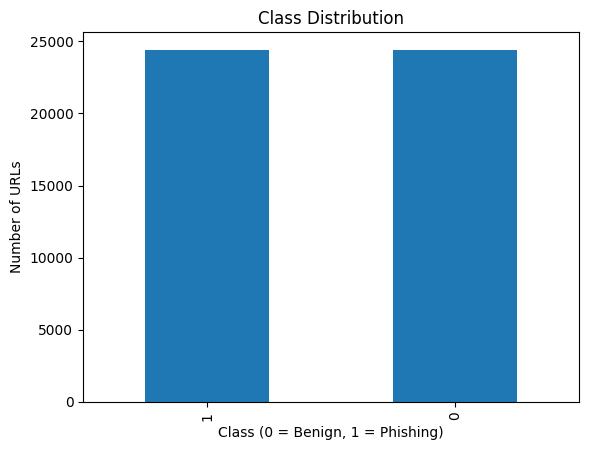

In [5]:
# Class Distribution

plt.figure()

df["label"].value_counts().plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class (0 = Benign, 1 = Phishing)")
plt.ylabel("Number of URLs")

plt.show()

In [6]:
# Data Preparation

X_text = df["url"].astype(str)
y = df["label"]

In [7]:
# Model Evaluation - Helper 
def evaluate(model, X, y, name):

    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:,1]

    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc = roc_auc_score(y, y_prob)

    print(f"\n{name}")
    print(classification_report(y, y_pred, digits=4))

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "roc": roc_curve(y, y_prob),
        "cm": confusion_matrix(y, y_pred)
    }

In [8]:
# Performance Plotter - Helper
def plot_performance_bars(test, title):

  metrics = ["accuracy","precision","recall","f1","auc"]
  scores = [test[m] for m in metrics]

  plt.figure(figsize=(8,4))
  plt.bar(metrics, scores)

  for i,v in enumerate(scores):
    plt.text(i, v+0.002, f"{v:.4f}", ha="center")

  plt.ylim(0.8,1.01)
  plt.ylabel("Score")
  plt.title(title)

  plt.show()

In [9]:
# Loading the Pretrained Model

lr = joblib.load("saved_models/minilm_logreg_model.joblib")

embedder = SentenceTransformer("saved_models/minilm_embedder")

print("Models loaded successfully.")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6152.90it/s]


Models loaded successfully.


In [10]:
# Generating MiniLM Embeddings

print("\nGenerating MiniLM embeddings...")

X_emb = embedder.encode(
    X_text.tolist(),
    batch_size=64,
    show_progress_bar=True
)


Generating MiniLM embeddings...


Batches: 100%|██████████| 763/763 [00:17<00:00, 42.93it/s]


In [11]:
# Model Evaluation
llm_test = evaluate(
    lr,
    X_emb,
    y,
    "MiniLM + Logistic Regression – External (test) Dataset"
)


MiniLM + Logistic Regression – External (test) Dataset
              precision    recall  f1-score   support

           0     0.9024    0.8613    0.8814     24406
           1     0.8673    0.9068    0.8866     24406

    accuracy                         0.8841     48812
   macro avg     0.8849    0.8841    0.8840     48812
weighted avg     0.8849    0.8841    0.8840     48812



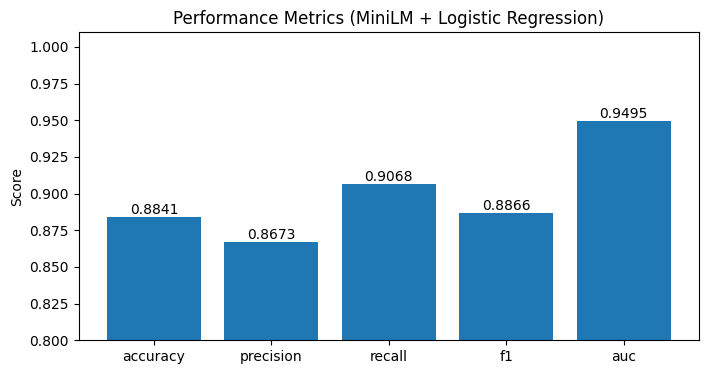

In [12]:
# Performance Plot

plot_performance_bars(
    llm_test,
    "Performance Metrics (MiniLM + Logistic Regression)"
)

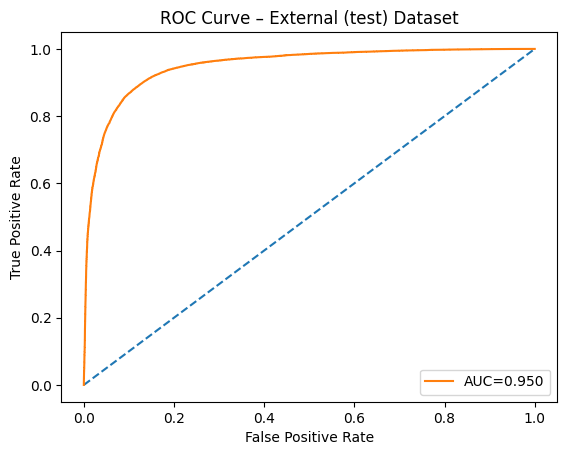

In [13]:
# ROC Curve
plt.figure()

plt.plot([0,1],[0,1], linestyle="--")

plt.plot(
    llm_test["roc"][0],
    llm_test["roc"][1],
    label=f"AUC={llm_test['auc']:.3f}"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve – External (test) Dataset")

plt.legend()

plt.show()

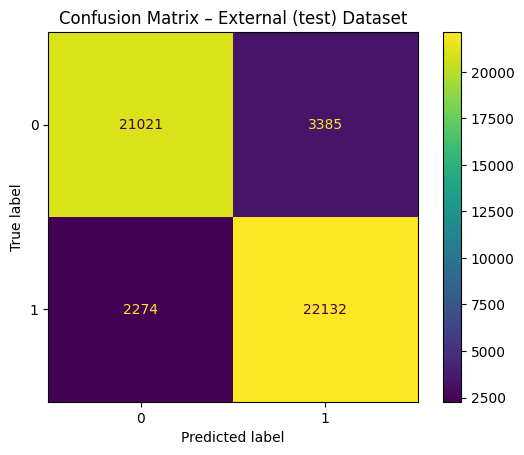

In [14]:
# Confusion Matrix

disp = ConfusionMatrixDisplay(llm_test["cm"])

disp.plot()

plt.title("Confusion Matrix – External (test) Dataset")

plt.show()

In [15]:
# Results Summary

results = pd.DataFrame({
    "Model": ["MiniLM + Logistic Regression (External (test) Dataset)"],
    "Accuracy": [llm_test["accuracy"]],
    "Precision": [llm_test["precision"]],
    "Recall": [llm_test["recall"]],
    "F1": [llm_test["f1"]],
    "ROC AUC": [llm_test["auc"]]
})

print("\nEvaluation Summary\n")

display(results)


Evaluation Summary



,Model,Accuracy,Precision,Recall,F1,ROC AUC
0,MiniLM + Logistic Regression (External (test) ...,0.884065,0.867343,0.906826,0.886645,0.949528


In [16]:
# Manual Test Case

test_urls = [
    "https://www.google.com",
    "http://secure-login-paypal-update.com/login"
]

print("\nManual Test Cases")

embeddings = embedder.encode(test_urls)

predictions = lr.predict(embeddings)
probabilities = lr.predict_proba(embeddings)[:,1]

for url, pred, prob in zip(test_urls, predictions, probabilities):

    label = "Phishing" if pred == 1 else "Benign"

    print(f"\nURL: {url}")
    print(f"Prediction: {label}")
    print(f"Phishing Probability: {prob:.4f}")


Manual Test Cases

URL: https://www.google.com
Prediction: Benign
Phishing Probability: 0.0005

URL: http://secure-login-paypal-update.com/login
Prediction: Phishing
Phishing Probability: 0.9264
